## Dimensionality Reduction and Ordination

After preprocessing and CLR transformation, the dataset remains high-dimensional, containing thousands of Metagenomic Species Pangenomes (MSPs). Microbial data is characterized by extreme sparsity and high dimensionality, which can obscure underlying biological patterns through technical noise and over-plotting. To extract meaningful biological signals, we employ dimensionality reduction techniques.

### 1. Why Dimensionality Reduction?

In line with recommendations for high‑dimensional omics visualization, we first applied PCA to summarize major compositional gradients and reduce noise in the gut microbiome profiles, and then ran t‑SNE on the leading PCs to capture nonlinear local neighborhood structure while maintaining computational efficiency ()

Working directly with thousands of features is computationally expensive and statistically challenging. We use a two-step ordination approach to resolve this:

- **Principal Component Analysis (PCA):** A linear method used to project the data into a lower-dimensional space while preserving the maximum variance. It acts as a noise filter, allowing us to focus on the primary axes of biological variation.

- **t-distributed Stochastic Neighbor Embedding (t-SNE):** A non-linear method specifically designed for visualizing high-dimensional clusters. While PCA captures global variance, t-SNE excels at resolving local neighborhood structures, making it easier to see if samples from similar backgrounds truly group together.

### 2. From Geography to Global Signatures



### 3. Implementation

The following cells will:

1. Perform **PCA** to stabilize the data and identify the main drivers of variance.
2. Execute **t-SNE** (initialized with PCA) to visualize the data in 2D space.

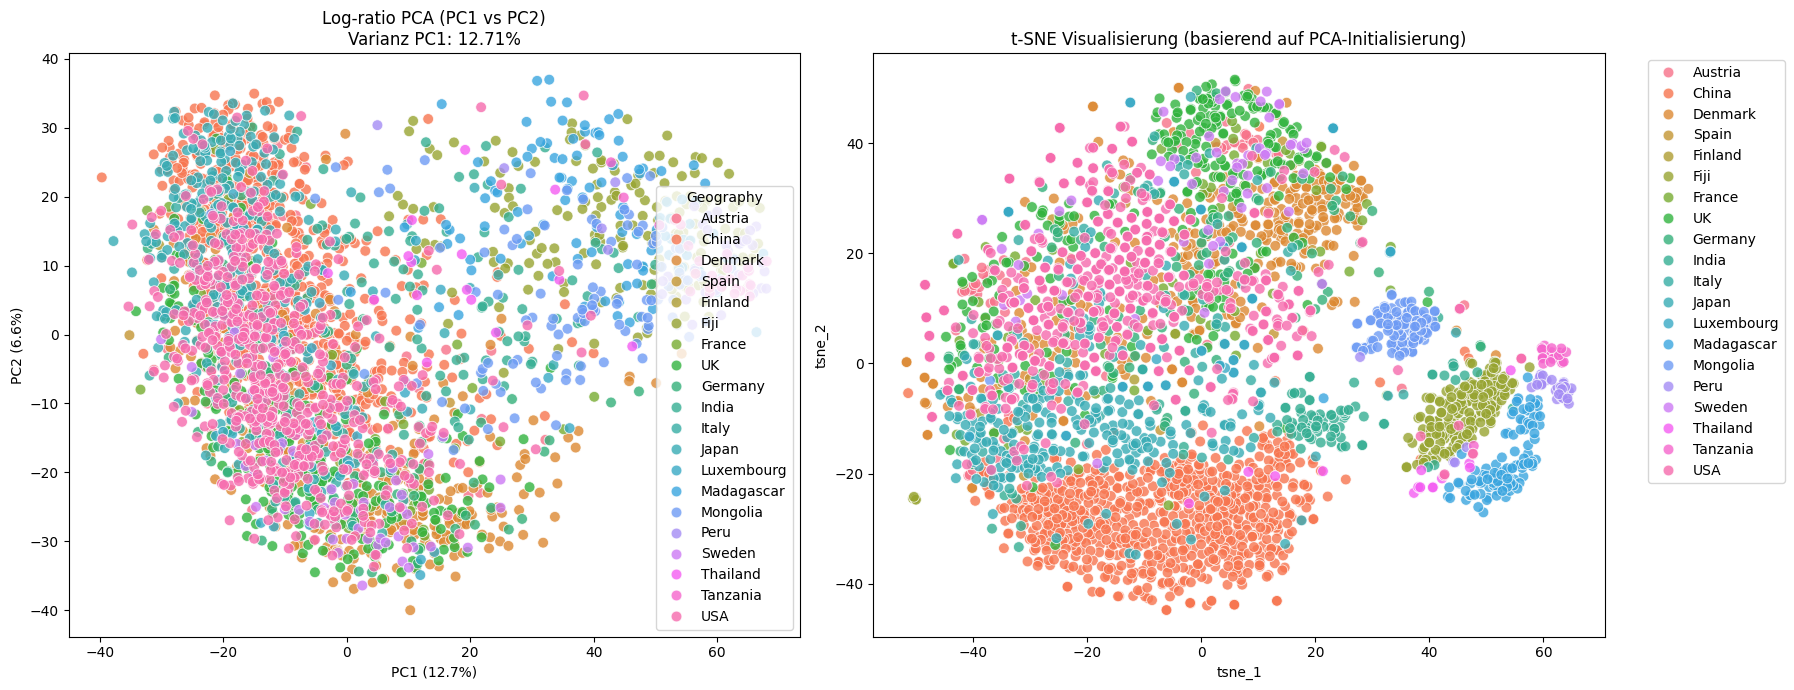

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Daten laden
# Ersetze den Pfad durch deine tatsächliche Datei
file_path = '../data/processed/06_clr_healthy_data.csv'
df = pd.read_csv(file_path)

# Drop all columns that dont start with "msp" and Geography
df = df[df.columns[df.columns.str.startswith('msp') | df.columns.str.startswith('Geography')]]

# Identify features and labels
features = [col for col in df.columns if col.startswith('msp')]


X = df[features]
labels = df['Geography']  # Deine Zielvariable für die Einfärbung

# 2. PCA durchführen
# Wir reduzieren zuerst auf z.B. 50 Komponenten, um Rauschen zu filtern
pca = PCA(n_components=0.95) # Behält 95% der Varianz
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['Geography'] = labels

# 3. t-SNE durchführen
# Best Practice: t-SNE auf den PCA-Ergebnissen berechnen
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X_pca)

df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['Geography'] = labels

# 4. Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot PCA
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Geography', ax=ax1, palette='husl', s=60, alpha=0.8)
ax1.set_title(f'Log-ratio PCA (PC1 vs PC2)\nVarianz PC1: {pca.explained_variance_ratio_[0]:.2%}')
ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')

# Plot t-SNE
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='Geography', ax=ax2, palette='husl', s=60, alpha=0.8)
ax2.set_title('t-SNE Visualisierung (basierend auf PCA-Initialisierung)')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()




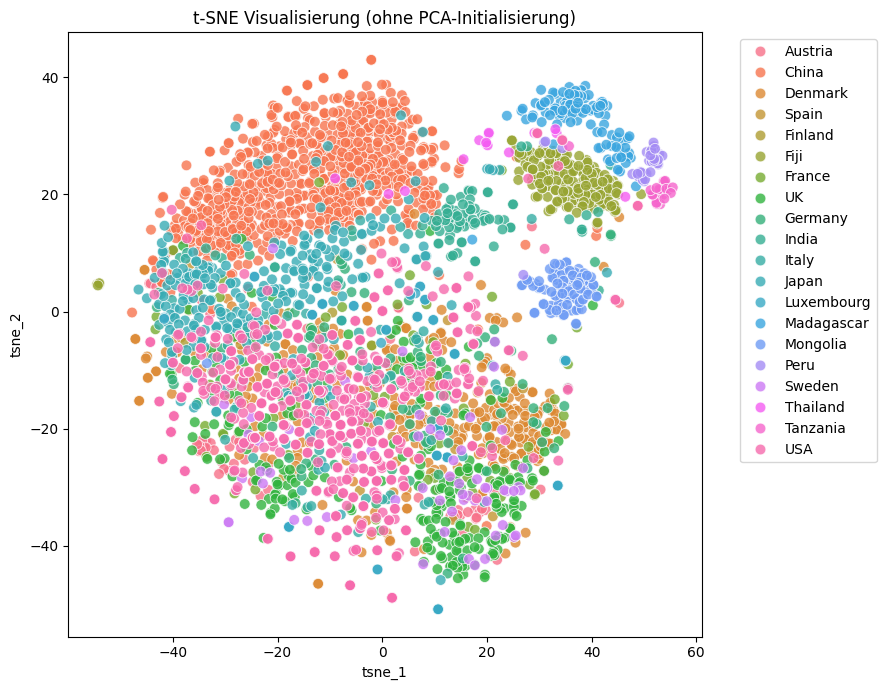

In [3]:
# performing TSNA on the original data without PCA
tsne_original = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
X_tsne_original = tsne_original.fit_transform(X)
df_tsne_original = pd.DataFrame(X_tsne_original, columns=['tsne_1', 'tsne_2'])
df_tsne_original['Geography'] = labels
# Plot t-SNE on original data
plt.figure(figsize=(9, 7))
sns.scatterplot(data=df_tsne_original, x='tsne_1', y='tsne_2', hue='Geography', palette='husl', s=60, alpha=0.8)
plt.title('t-SNE Visualisierung (ohne PCA-Initialisierung)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


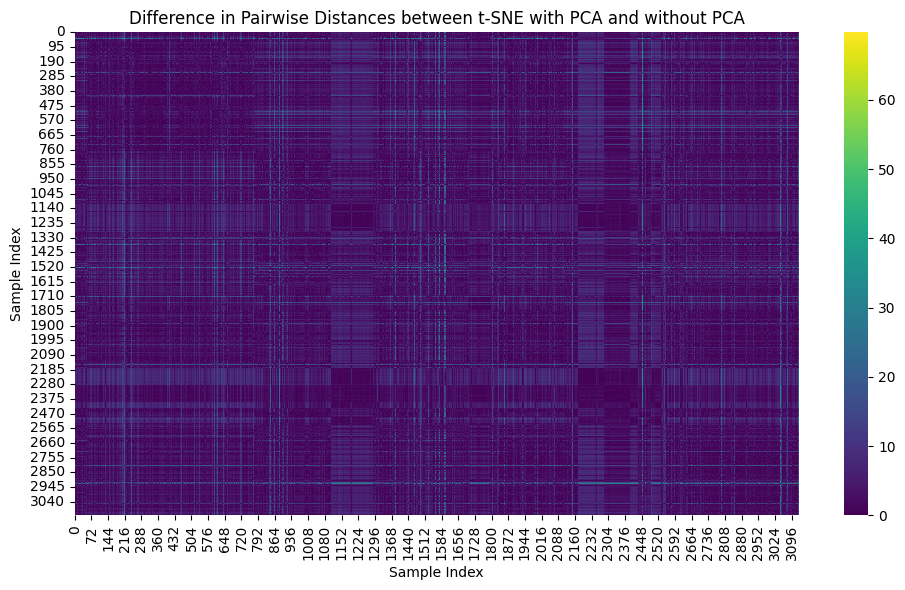

In [4]:
# calcuating the difference between the two t-SNE results
from sklearn.metrics import pairwise_distances
# Calculate pairwise distances for both t-SNE results
dist_tsne_pca = pairwise_distances(X_tsne)
dist_tsne_original = pairwise_distances(X_tsne_original)
# Calculate the difference in distances
distance_diff = np.abs(dist_tsne_pca - dist_tsne_original)
# Visualize the distance differences
plt.figure(figsize=(10, 6))
sns.heatmap(distance_diff, cmap='viridis')
plt.title('Difference in Pairwise Distances between t-SNE with PCA and without PCA')
plt.xlabel('Sample Index')
plt.ylabel('Sample Index')
plt.tight_layout()
plt.show()

In [5]:
# Some summary statistics of the distance differences
print("Summary of Distance Differences between t-SNE with PCA and without PCA:")
print(f"Mean Distance Difference: {np.mean(distance_diff):.4f}")
print(f"Median Distance Difference: {np.median(distance_diff):.4f}")    

Summary of Distance Differences between t-SNE with PCA and without PCA:
Mean Distance Difference: 4.3177
Median Distance Difference: 3.1768


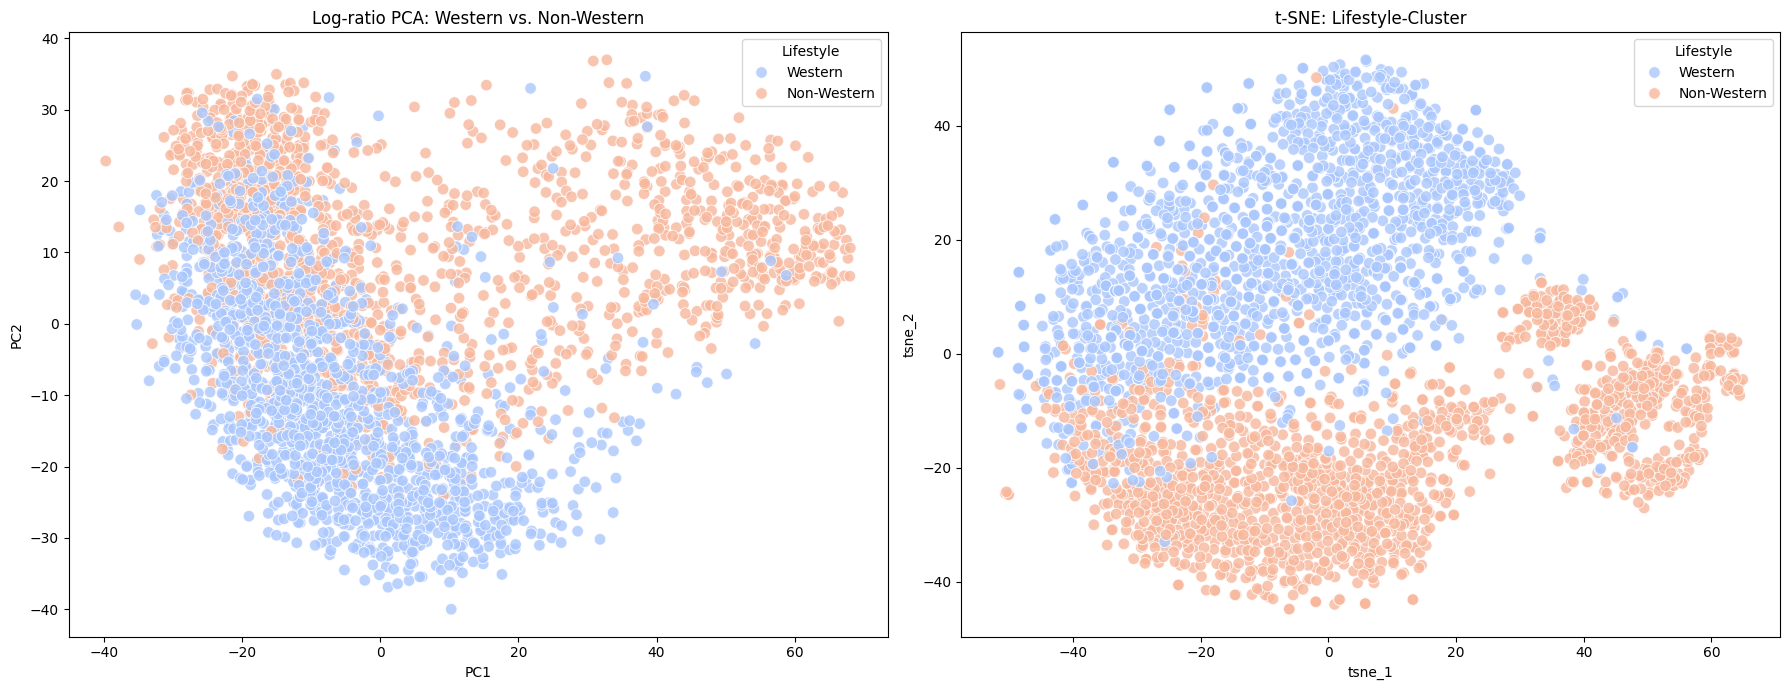

In [11]:
# 1. Lifestyle-Mapping definieren
lifestyle_map = {
    'Austria': 'Western', 'Denmark': 'Western', 'Spain': 'Western', 
    'Finland': 'Western', 'France': 'Western', 'UK': 'Western', 
    'Germany': 'Western', 'Italy': 'Western', 'Luxembourg': 'Western', 'Sweden': 'Western',
    'USA': 'Western',
    'China': 'Non-Western', 'India': 'Non-Western', 'Japan': 'Non-Western', 
    'Mongolia': 'Non-Western', 'Thailand': 'Non-Western',
    'Peru': 'Non-Western', 'Madagascar': 'Non-Western', 
    'Tanzania': 'Non-Western', 'Fiji': 'Non-Western'
}

# Neue Spalte 'Lifestyle' erstellen
df['Lifestyle'] = df['Geography'].map(lifestyle_map)

# Labels für die Analyse aktualisieren
labels = df['Lifestyle']

# 2. PCA durchführen (auf den bereits vorhandenen X-Daten)
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
df_pca['Lifestyle'] = labels

# 3. t-SNE durchführen
tsne = TSNE(n_components=2, perplexity=30, init='pca', learning_rate='auto', random_state=42)
X_tsne = tsne.fit_transform(X_pca)

df_tsne = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
df_tsne['Lifestyle'] = labels

# 4. Visualisierung
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Plot PCA nach Lifestyle
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Lifestyle', ax=ax1, palette='coolwarm', s=70, alpha=0.8)
ax1.set_title('Log-ratio PCA: Western vs. Non-Western')

# Plot t-SNE nach Lifestyle
sns.scatterplot(data=df_tsne, x='tsne_1', y='tsne_2', hue='Lifestyle', ax=ax2, palette='coolwarm', s=70, alpha=0.8)
ax2.set_title('t-SNE: Lifestyle-Cluster')

plt.tight_layout()
plt.show()